<a href="https://colab.research.google.com/github/derektorquette/reconhecimento-de-emocoes-com-tensorflow-e-python/blob/main/testes_detector_emocao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Testando o Modelo do Detector de Emoções

## Etapa 1 - Importando as bibliotecas

In [ ]:
import cv2
import numpy as np
import pandas as pd
from google.colab.patches import cv2_imshow
import zipfile

In [ ]:
%tensorflow_version 2.x


Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [ ]:
import tensorflow as tf
print(tf.__version__)


2.20.0


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing import image



## Etapa 2 - Conectando com o Drive e Acessando os arquivos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
patch = "/content/drive/MyDrive/CURSOS LIVRES FORMAÇÃO COMPLEMENTAR/Reconhecimento de Emoções com TensorFlow 2.0 e Python/Material"

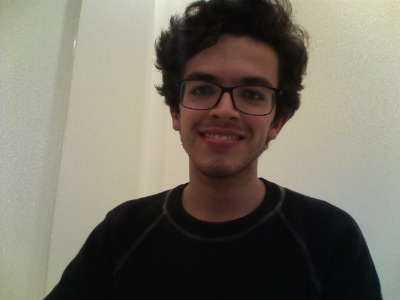

In [ ]:
imagem = cv2.imread('/content/drive/MyDrive/CURSOS LIVRES FORMAÇÃO COMPLEMENTAR/Reconhecimento de Emoções com TensorFlow 2.0 e Python/Material/Material/testes/teste_gabriel.png')
cv2_imshow(imagem)

## Etapa 3 - Testando o Detector

### Carrregamento de modelos


In [ ]:
!pip install tf-keras

In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
from tf_keras.models import load_model

cascade_faces = "/content/drive/MyDrive/CURSOS LIVRES FORMAÇÃO COMPLEMENTAR/Reconhecimento de Emoções com TensorFlow 2.0 e Python/Material/Material/haarcascade_frontalface_default.xml"
caminho_modelo = "/content/drive/MyDrive/CURSOS LIVRES FORMAÇÃO COMPLEMENTAR/Reconhecimento de Emoções com TensorFlow 2.0 e Python/Material/Material/modelo_01_expressoes.h5"

face_detection = cv2.CascadeClassifier(cascade_faces)
classificador_emocoes = load_model(caminho_modelo, compile=False)

expressoes = ["Raiva", "Nojo", "Medo", "Feliz", "Triste", "Surpreso", "Neutro"]

print("Modelo carregado com sucesso!")

Modelo carregado com sucesso!


### Detecção de Faces

In [ ]:
imagem.shape

(300, 400, 3)

In [ ]:
original = imagem.copy()
faces = face_detection.detectMultiScale(original, scaleFactor=1.1, minNeighbors=3, minSize=(20, 20))

In [ ]:
faces

array([[162,  40, 128, 128]], dtype=int32)

In [ ]:
len(faces)

1

In [ ]:
faces.shape

(1, 4)

### Extração do ROI

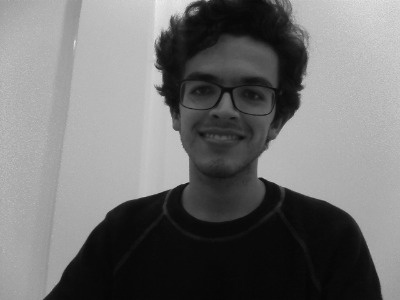

In [ ]:
cinza = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
cv2_imshow(cinza)

In [ ]:
cinza.shape

(300, 400)

In [ ]:
roi = cinza[40:40 + 128, 162:162 + 128]

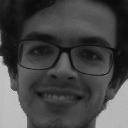

In [ ]:
cv2_imshow(roi)

In [ ]:
roi.shape

(128, 128)

array([[ 39,  37,  28, ...,  25,  29,  34],
       [ 34,  32,  25, ...,  24,  24,  29],
       [ 31,  33,  30, ...,  23,  22,  26],
       ...,
       [184, 185, 186, ..., 180, 181, 181],
       [184, 185, 186, ..., 179, 181, 180],
       [184, 185, 187, ..., 180, 181, 180]], dtype=uint8)
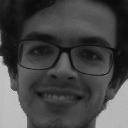

In [ ]:
roi

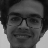

In [ ]:
roi = cv2.resize(roi, (48, 48)) # é importante reduzir a imagem para testes
cv2_imshow(roi)

In [ ]:
roi.dtype # precisamos normalizar esses dados, deixando entre a escala 0 e 1

dtype('uint8')

In [ ]:
roi = roi.astype("float")
roi.dtype

dtype('float64')

In [ ]:
roi

array([[ 33.,  29.,  38., ...,  16.,  22.,  25.],
       [ 32.,  37.,  37., ...,  16.,  20.,  25.],
       [ 32.,  36.,  31., ...,  17.,  21.,  25.],
       ...,
       [186., 189., 189., ..., 181., 181., 180.],
       [185., 188., 189., ..., 180., 181., 180.],
       [185., 188., 188., ..., 179., 180., 181.]])

In [ ]:
roi = roi/225 # transformando entre a escala 0 e 1
roi

array([[0.14666667, 0.12888889, 0.16888889, ..., 0.07111111, 0.09777778,
        0.11111111],
       [0.14222222, 0.16444444, 0.16444444, ..., 0.07111111, 0.08888889,
        0.11111111],
       [0.14222222, 0.16      , 0.13777778, ..., 0.07555556, 0.09333333,
        0.11111111],
       ...,
       [0.82666667, 0.84      , 0.84      , ..., 0.80444444, 0.80444444,
        0.8       ],
       [0.82222222, 0.83555556, 0.84      , ..., 0.8       , 0.80444444,
        0.8       ],
       [0.82222222, 0.83555556, 0.83555556, ..., 0.79555556, 0.8       ,
        0.80444444]])

In [ ]:
roi = img_to_array(roi) # adicionando uma dimensão, transformando em 3
roi.shape

(48, 48, 1)

In [ ]:
roi = np.expand_dims(roi, axis=0) # adicionando uma dimensão, transformando em 4
roi.shape

(1, 48, 48, 1)

### Previsões

In [ ]:
preds = classificador_emocoes.predict(roi)[0]

1/1 [==============================] - 0s 228ms/step


In [ ]:
len(preds)

7

In [ ]:
emotion_probability = np.max(preds)
emotion_probability

np.float32(0.9884843)

In [ ]:
preds.argmax()

np.int64(3)

In [ ]:
label = expressoes[preds.argmax()]
label

'Feliz'

### Resultados

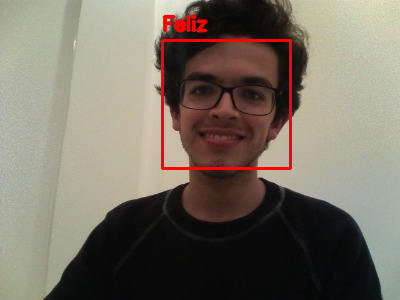

In [ ]:
cv2.putText(original, label, (162, 40 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 0, 255), 2, cv2.LINE_AA)
cv2.rectangle(original, (162, 40), (162 + 128, 40 + 128), (0, 0, 255), 2)
cv2_imshow(original)

In [ ]:
probabilidades = np.ones((259, 300, 3), dtype="uint8") * 255
probabilidades.shape

(259, 300, 3)

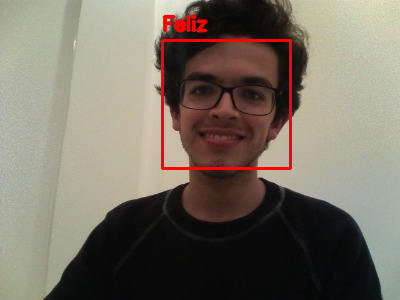

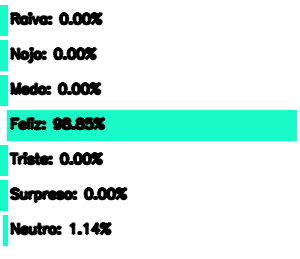

In [ ]:
cv2_imshow(original)
if len(faces) == 1:
  for(i, (emotion, prob)) in enumerate(zip(expressoes, preds)):
    # print(i, emotion, prob)
    text = "{}: {:.2f}%".format(emotion, prob * 100)
    w = int(prob * 300)
    cv2.rectangle(probabilidades, (7, (i * 35) + 5), (w, (i * 35) + 35), (200, 250, 25), -1)
    cv2.putText(probabilidades, text, (10, (i * 35) + 23), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 2, cv2.LINE_AA)
  cv2_imshow(probabilidades)
